<a href="https://colab.research.google.com/github/fernandocesaraviles-tech/ai-bias-audit/blob/main/src/01_load_and_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
01_load_and_explore.py

Paso 1 del proyecto: cargar el dataset Adult Income (Census Income) y hacer
una primera exploración enfocada en detectar señales de sesgo en los DATOS
CRUDOS, antes de entrenar cualquier modelo.

Tarea del dataset: predecir si una persona gana más o menos de 50k USD/año
a partir de variables demográficas y laborales.
"""

import pandas as pd
from sklearn.datasets import fetch_openml

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


def load_data() -> pd.DataFrame:
    """Descarga (o carga desde caché local) el dataset Adult Income."""
    adult = fetch_openml(name="adult", version=2, as_frame=True)
    df = adult.frame.copy()

    if "class" in df.columns and "income" not in df.columns:
        df = df.rename(columns={"class": "income"})

    return df


def resumen_general(df: pd.DataFrame) -> None:
    print("=" * 70)
    print("RESUMEN GENERAL DEL DATASET")
    print("=" * 70)
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "  (sin nulos)")
    print("\nPrimeras filas:")
    print(df.head())


def distribucion_objetivo(df: pd.DataFrame, target_col: str = "income") -> None:
    print("\n" + "=" * 70)
    print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (income)")
    print("=" * 70)
    print(df[target_col].value_counts(normalize=True).round(3))


def tasa_positiva_por_grupo(df: pd.DataFrame, atributo: str, target_col: str = "income") -> pd.Series:
    """
    Calcula la proporción de personas con ingreso '>50K' dentro de cada
    grupo del atributo sensible indicado (sex, race, etc).
    """
    tasa = df.groupby(atributo)[target_col].apply(
        lambda s: s.astype(str).str.contains(">50K").mean()
    )
    return tasa.sort_values(ascending=False)


def indice_impacto_dispar(tasas: pd.Series) -> float:
    """
    Calcula el 'disparate impact ratio': tasa del grupo con peor resultado
    dividido tasa del grupo con mejor resultado. Un valor por debajo de 0.8
    suele tomarse como señal de alerta (regla del 80%, usada en EEOC/EEUU).
    """
    return round(tasas.min() / tasas.max(), 3)


def main():
    df = load_data()

    resumen_general(df)
    distribucion_objetivo(df)

    print("\n" + "=" * 70)
    print("TASA DE INGRESO '>50K' POR SEXO")
    print("=" * 70)
    tasas_sexo = tasa_positiva_por_grupo(df, "sex")
    print(tasas_sexo.round(3))
    print(f"\nÍndice de impacto dispar (sexo): {indice_impacto_dispar(tasas_sexo)}")
    print("(valores < 0.8 son señal de alerta según la 'regla del 80%')")

    print("\n" + "=" * 70)
    print("TASA DE INGRESO '>50K' POR RAZA")
    print("=" * 70)
    tasas_raza = tasa_positiva_por_grupo(df, "race")
    print(tasas_raza.round(3))
    print(f"\nÍndice de impacto dispar (raza): {indice_impacto_dispar(tasas_raza)}")


if __name__ == "__main__":
    main()

RESUMEN GENERAL DEL DATASET
Filas: 48,842 | Columnas: 15

Tipos de datos:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income            category
dtype: object

Valores nulos por columna:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Primeras filas:
   age  workclass  fnlwgt     education  education-num      marital-status         occupation relationship   race  \
0   25    Private  226802          11th              7       Never-married  Machine-op-inspct    Own-child  Black   
1   38    Private   89814       HS-grad              9  Married-civ-spouse    Farming-fishing      Husband  White   
2   28  Local-gov  336951    

/tmp/ipykernel_524/1998204186.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = df.groupby(atributo)[target_col].apply(
/tmp/ipykernel_524/1998204186.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = df.groupby(atributo)[target_col].apply(


In [ ]:
"""
02_baseline_model.py

Paso 2: entrenar un modelo base (regresión logística) para predecir el
ingreso, y comparar el sesgo en las PREDICCIONES del modelo contra el
sesgo que ya vimos en los datos crudos (paso 1).
"""

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)


def load_data() -> pd.DataFrame:
    adult = fetch_openml(name="adult", version=2, as_frame=True)
    df = adult.frame.copy()
    if "class" in df.columns and "income" not in df.columns:
        df = df.rename(columns={"class": "income"})
    df = df.dropna()  # simplificación para el modelo base: descartamos filas con nulos
    return df


def preparar_datos(df: pd.DataFrame):
    y = (df["income"].astype(str).str.contains(">50K")).astype(int)
    X = df.drop(columns=["income"])
    # convertimos columnas categóricas (sex, race, workclass, etc.) a
    # variables numéricas mediante one-hot encoding
    X = pd.get_dummies(X, drop_first=True)
    return X, y


def tasa_positiva_prediccion(df_test: pd.DataFrame, y_pred, atributo: str) -> pd.Series:
    temp = df_test.copy()
    temp["prediccion"] = y_pred
    return temp.groupby(atributo, observed=True)["prediccion"].mean().sort_values(ascending=False)


def indice_impacto_dispar(tasas: pd.Series) -> float:
    return round(tasas.min() / tasas.max(), 3)


def main():
    df = load_data()
    X, y = preparar_datos(df)

    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X, y, df, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)

    print("=" * 70)
    print("DESEMPEÑO DEL MODELO BASE")
    print("=" * 70)
    print(f"Precisión (accuracy): {accuracy_score(y_test, y_pred):.3f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

    print("\n" + "=" * 70)
    print("SESGO EN LAS PREDICCIONES DEL MODELO (no en los datos crudos)")
    print("=" * 70)

    tasas_sexo_pred = tasa_positiva_prediccion(df_test, y_pred, "sex")
    print("\nTasa de predicción '>50K' por sexo:")
    print(tasas_sexo_pred.round(3))
    print(f"Índice de impacto dispar (sexo, predicciones): {indice_impacto_dispar(tasas_sexo_pred)}")

    tasas_raza_pred = tasa_positiva_prediccion(df_test, y_pred, "race")
    print("\nTasa de predicción '>50K' por raza:")
    print(tasas_raza_pred.round(3))
    print(f"Índice de impacto dispar (raza, predicciones): {indice_impacto_dispar(tasas_raza_pred)}")

    print("\n" + "=" * 70)
    print("COMPARACIÓN: DATOS CRUDOS (paso 1) vs PREDICCIONES DEL MODELO")
    print("=" * 70)
    print("Datos crudos        -> sexo: 0.36   | raza: 0.435")
    print(f"Predicciones modelo -> sexo: {indice_impacto_dispar(tasas_sexo_pred)}  | raza: {indice_impacto_dispar(tasas_raza_pred)}")


if __name__ == "__main__":
    main()

DESEMPEÑO DEL MODELO BASE
Precisión (accuracy): 0.846

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K       0.73      0.60      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045


SESGO EN LAS PREDICCIONES DEL MODELO (no en los datos crudos)

Tasa de predicción '>50K' por sexo:
sex
Male      0.262
Female    0.078
Name: prediccion, dtype: float64
Índice de impacto dispar (sexo, predicciones): 0.299

Tasa de predicción '>50K' por raza:
race
Asian-Pac-Islander    0.283
White                 0.215
Black                 0.092
Amer-Indian-Eskimo    0.089
Other                 0.062
Name: prediccion, dtype: float64
Índice de impacto dispar (raza, predicciones): 0.221

COMPARACIÓN: DATOS CRUDOS (paso 1) vs PREDICCIONES DEL MODELO
Datos crudos        -> sexo: 0.36   | r

In [ ]:
 !pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.6 MB/s eta 0:00:00


In [ ]:
"""
03_fairness_audit.py

Paso 3: mitigar el sesgo detectado en el modelo base usando Fairlearn,
aplicando post-procesamiento sobre las predicciones para igualar la tasa
de selección entre hombres y mujeres (constraint: demographic_parity).

IMPORTANTE: en Colab, antes de correr este script, ejecutá en una celda
aparte:
    !pip install fairlearn
"""

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from fairlearn.postprocessing import ThresholdOptimizer

pd.set_option("display.max_columns", None)


def load_data() -> pd.DataFrame:
    adult = fetch_openml(name="adult", version=2, as_frame=True)
    df = adult.frame.copy()
    if "class" in df.columns and "income" not in df.columns:
        df = df.rename(columns={"class": "income"})
    df = df.dropna()
    return df


def preparar_datos(df: pd.DataFrame):
    y = (df["income"].astype(str).str.contains(">50K")).astype(int)
    X = df.drop(columns=["income"])
    X = pd.get_dummies(X, drop_first=True)
    return X, y


def tasa_positiva_prediccion(df_test: pd.DataFrame, y_pred, atributo: str) -> pd.Series:
    temp = df_test.copy()
    temp["prediccion"] = y_pred
    return temp.groupby(atributo, observed=True)["prediccion"].mean().sort_values(ascending=False)


def indice_impacto_dispar(tasas: pd.Series) -> float:
    return round(tasas.min() / tasas.max(), 3)


def main():
    df = load_data()
    X, y = preparar_datos(df)

    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X, y, df, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Modelo base (igual al paso 2) ---
    modelo_base = LogisticRegression(max_iter=1000)
    modelo_base.fit(X_train_scaled, y_train)
    y_pred_base = modelo_base.predict(X_test_scaled)

    # --- Mitigación con Fairlearn ---
    # Ajustamos el umbral de decisión por separado para cada grupo de sexo,
    # buscando que la proporción de predicciones ">50K" sea similar entre
    # hombres y mujeres (demographic parity), sin re-entrenar el modelo.
    mitigador = ThresholdOptimizer(
        estimator=modelo_base,
        constraints="demographic_parity",
        predict_method="predict_proba",
        prefit=True,
    )
    mitigador.fit(X_train_scaled, y_train, sensitive_features=df_train["sex"])
    y_pred_mitigado = mitigador.predict(X_test_scaled, sensitive_features=df_test["sex"])

    print("=" * 70)
    print("ACCURACY: MODELO BASE vs MODELO MITIGADO")
    print("=" * 70)
    print(f"Accuracy modelo base:     {accuracy_score(y_test, y_pred_base):.3f}")
    print(f"Accuracy modelo mitigado: {accuracy_score(y_test, y_pred_mitigado):.3f}")
    print("(es normal y esperable que la accuracy baje un poco: es el")
    print(" costo de reducir el sesgo — la 'tensión precisión vs equidad')")

    tasas_base = tasa_positiva_prediccion(df_test, y_pred_base, "sex")
    tasas_mitigado = tasa_positiva_prediccion(df_test, y_pred_mitigado, "sex")

    print("\n" + "=" * 70)
    print("ÍNDICE DE IMPACTO DISPAR POR SEXO — ANTES vs DESPUÉS DE MITIGAR")
    print("=" * 70)
    print("Datos crudos (paso 1):     0.36")
    print(f"Modelo base (paso 2):      {indice_impacto_dispar(tasas_base)}")
    print(f"Modelo mitigado (paso 3):  {indice_impacto_dispar(tasas_mitigado)}")

    print("\nTasas de predicción '>50K' por sexo, modelo mitigado:")
    print(tasas_mitigado.round(3))


if __name__ == "__main__":
    main()

ACCURACY: MODELO BASE vs MODELO MITIGADO
Accuracy modelo base:     0.846
Accuracy modelo mitigado: 0.832
(es normal y esperable que la accuracy baje un poco: es el
 costo de reducir el sesgo — la 'tensión precisión vs equidad')

ÍNDICE DE IMPACTO DISPAR POR SEXO — ANTES vs DESPUÉS DE MITIGAR
Datos crudos (paso 1):     0.36
Modelo base (paso 2):      0.299
Modelo mitigado (paso 3):  0.935

Tasas de predicción '>50K' por sexo, modelo mitigado:
sex
Female    0.175
Male      0.163
Name: prediccion, dtype: float64


In [3]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 8.2 MB/s eta 0:00:00


In [4]:
"""
04_fairness_audit_race.py

Paso 4: mitigar el sesgo por RAZA (el que quedó peor: 0.221 en el modelo
base), usando la misma técnica de post-procesamiento con Fairlearn que
en el paso 3, pero ahora con "race" como atributo sensible.

Nota: race tiene 5 categorías (no 2 como sexo), Fairlearn admite
atributos sensibles con más de dos grupos sin cambios en el código.

IMPORTANTE: en Colab, si no lo instalaste en esta sesión, ejecutá antes
en una celda aparte:
    !pip install fairlearn
"""

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from fairlearn.postprocessing import ThresholdOptimizer

pd.set_option("display.max_columns", None)


def load_data() -> pd.DataFrame:
    adult = fetch_openml(name="adult", version=2, as_frame=True)
    df = adult.frame.copy()
    if "class" in df.columns and "income" not in df.columns:
        df = df.rename(columns={"class": "income"})
    df = df.dropna()
    return df


def preparar_datos(df: pd.DataFrame):
    y = (df["income"].astype(str).str.contains(">50K")).astype(int)
    X = df.drop(columns=["income"])
    X = pd.get_dummies(X, drop_first=True)
    return X, y


def tasa_positiva_prediccion(df_test: pd.DataFrame, y_pred, atributo: str) -> pd.Series:
    temp = df_test.copy()
    temp["prediccion"] = y_pred
    return temp.groupby(atributo, observed=True)["prediccion"].mean().sort_values(ascending=False)


def indice_impacto_dispar(tasas: pd.Series) -> float:
    return round(tasas.min() / tasas.max(), 3)


def main():
    df = load_data()
    X, y = preparar_datos(df)

    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X, y, df, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Modelo base (idéntico a los pasos 2 y 3) ---
    modelo_base = LogisticRegression(max_iter=1000)
    modelo_base.fit(X_train_scaled, y_train)
    y_pred_base = modelo_base.predict(X_test_scaled)

    # --- Mitigación con Fairlearn, ahora usando "race" ---
    mitigador = ThresholdOptimizer(
        estimator=modelo_base,
        constraints="demographic_parity",
        predict_method="predict_proba",
        prefit=True,
    )
    mitigador.fit(X_train_scaled, y_train, sensitive_features=df_train["race"])
    y_pred_mitigado = mitigador.predict(X_test_scaled, sensitive_features=df_test["race"])

    print("=" * 70)
    print("ACCURACY: MODELO BASE vs MODELO MITIGADO (por raza)")
    print("=" * 70)
    print(f"Accuracy modelo base:     {accuracy_score(y_test, y_pred_base):.3f}")
    print(f"Accuracy modelo mitigado: {accuracy_score(y_test, y_pred_mitigado):.3f}")

    tasas_base = tasa_positiva_prediccion(df_test, y_pred_base, "race")
    tasas_mitigado = tasa_positiva_prediccion(df_test, y_pred_mitigado, "race")

    print("\n" + "=" * 70)
    print("ÍNDICE DE IMPACTO DISPAR POR RAZA — ANTES vs DESPUÉS DE MITIGAR")
    print("=" * 70)
    print("Datos crudos (paso 1):     0.435")
    print(f"Modelo base (paso 2):      {indice_impacto_dispar(tasas_base)}")
    print(f"Modelo mitigado (paso 4):  {indice_impacto_dispar(tasas_mitigado)}")

    print("\nTasas de predicción '>50K' por raza, modelo mitigado:")
    print(tasas_mitigado.round(3))

    print("\nTasas de predicción '>50K' por raza, modelo base (para comparar):")
    print(tasas_base.round(3))


if __name__ == "__main__":
    main()

ACCURACY: MODELO BASE vs MODELO MITIGADO (por raza)
Accuracy modelo base:     0.846
Accuracy modelo mitigado: 0.842

ÍNDICE DE IMPACTO DISPAR POR RAZA — ANTES vs DESPUÉS DE MITIGAR
Datos crudos (paso 1):     0.435
Modelo base (paso 2):      0.221
Modelo mitigado (paso 4):  0.72

Tasas de predicción '>50K' por raza, modelo mitigado:
race
Amer-Indian-Eskimo    0.278
Black                 0.215
Asian-Pac-Islander    0.213
White                 0.208
Other                 0.200
Name: prediccion, dtype: float64

Tasas de predicción '>50K' por raza, modelo base (para comparar):
race
Asian-Pac-Islander    0.283
White                 0.215
Black                 0.092
Amer-Indian-Eskimo    0.089
Other                 0.062
Name: prediccion, dtype: float64


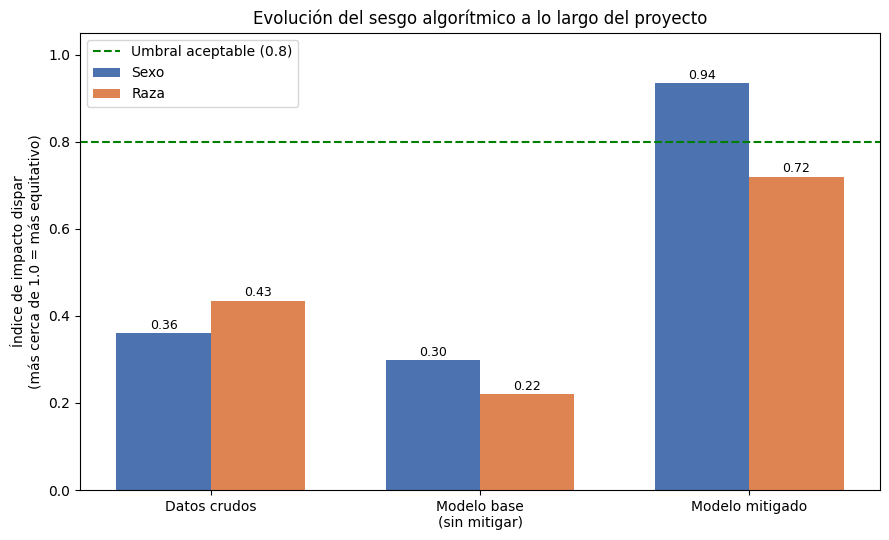

Gráfico guardado en docs/grafico_impacto_dispar.png


In [2]:
"""
05_visualizacion.py

Paso 5: gráfico comparativo final del proyecto. Resume en una sola
imagen los índices de impacto dispar por sexo y por raza, en las tres
etapas medidas: datos crudos, modelo base y modelo mitigado.

Los valores están "hardcodeados" (escritos directamente) porque ya los
obtuvimos y verificamos en los pasos 1 a 4 — no hace falta re-entrenar
nada para graficar.
"""

import matplotlib.pyplot as plt
import numpy as np

etapas = ["Datos crudos", "Modelo base\n(sin mitigar)", "Modelo mitigado"]

# valores obtenidos en los pasos 1, 2, 3 y 4
impacto_sexo = [0.36, 0.299, 0.935]
impacto_raza = [0.435, 0.221, 0.72]

umbral_aceptable = 0.8

x = np.arange(len(etapas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

barras_sexo = ax.bar(x - ancho / 2, impacto_sexo, ancho, label="Sexo", color="#4C72B0")
barras_raza = ax.bar(x + ancho / 2, impacto_raza, ancho, label="Raza", color="#DD8452")

ax.axhline(
    y=umbral_aceptable,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"Umbral aceptable ({umbral_aceptable})",
)

ax.set_ylabel("Índice de impacto dispar\n(más cerca de 1.0 = más equitativo)")
ax.set_title("Evolución del sesgo algorítmico a lo largo del proyecto")
ax.set_xticks(x)
ax.set_xticklabels(etapas)
ax.set_ylim(0, 1.05)
ax.legend()

# etiquetas con el valor numérico arriba de cada barra
for barras in (barras_sexo, barras_raza):
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(
            f"{altura:.2f}",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

plt.tight_layout()
import os
os.makedirs("docs", exist_ok=True)
plt.savefig("docs/grafico_impacto_dispar.png", dpi=150)
plt.show()

print("Gráfico guardado en docs/grafico_impacto_dispar.png")

In [1]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.0 MB/s eta 0:00:00


In [2]:
"""
04_monitor_agent.py

Paso 6: agente simple de monitoreo del modelo en producción.

Un agente inteligente, en su forma más simple (agente reactivo basado en
reglas), es un sistema que:
    1. Percibe su entorno (en este caso, nuevos lotes de datos que llegan)
    2. Evalúa esa percepción contra reglas o umbrales
    3. Decide y ejecuta una acción (en este caso, emitir una alerta)

Este agente automatiza el "Monitoreo continuo" descrito en el informe de
mitigación (docs/informe_mitigacion.md) y en el módulo de ISO 42001:
revisa si el modelo sigue funcionando bien (accuracy) y si sigue siendo
equitativo (índice de impacto dispar), y decide si hace falta
reentrenar.

IMPORTANTE: en Colab, antes de correr este script, ejecutá en una celda
aparte:
    !pip install fairlearn
"""

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from fairlearn.postprocessing import ThresholdOptimizer

pd.set_option("display.max_columns", None)

# Umbrales que definen cuándo el agente debe alertar. Estos valores
# vienen del informe de mitigación: 0.8 es la "regla del 80%" para
# impacto dispar, y 0.80 de accuracy es un piso razonable para este caso.
UMBRAL_ACCURACY_MINIMO = 0.80
UMBRAL_IMPACTO_DISPAR_MINIMO = 0.80


def load_data() -> pd.DataFrame:
    adult = fetch_openml(name="adult", version=2, as_frame=True)
    df = adult.frame.copy()
    if "class" in df.columns and "income" not in df.columns:
        df = df.rename(columns={"class": "income"})
    df = df.dropna()
    return df


def preparar_datos(df: pd.DataFrame):
    y = (df["income"].astype(str).str.contains(">50K")).astype(int)
    X = df.drop(columns=["income"])
    X = pd.get_dummies(X, drop_first=True)
    return X, y


def indice_impacto_dispar(df_batch: pd.DataFrame, y_pred, atributo: str) -> float:
    temp = df_batch.copy()
    temp["prediccion"] = y_pred
    tasas = temp.groupby(atributo, observed=True)["prediccion"].mean()
    return round(tasas.min() / tasas.max(), 3)


class AgenteMonitoreo:
    """
    Agente reactivo simple: percibe un lote (batch) de datos nuevos,
    evalúa el desempeño y la equidad del modelo sobre ese lote, y decide
    una acción según reglas fijas (umbrales).
    """

    def __init__(self, mitigador, scaler):
        self.mitigador = mitigador
        self.scaler = scaler
        self.historial = []

    def percibir_y_evaluar(self, X_batch, y_batch, df_batch, id_lote):
        """Percibe un lote nuevo y calcula sus métricas."""
        X_batch_scaled = self.scaler.transform(X_batch)
        y_pred = self.mitigador.predict(X_batch_scaled, sensitive_features=df_batch["sex"])

        resultado = {
            "lote": id_lote,
            "accuracy": accuracy_score(y_batch, y_pred),
            "impacto_dispar_sexo": indice_impacto_dispar(df_batch, y_pred, "sex"),
        }
        self.historial.append(resultado)
        return resultado

    def decidir_accion(self, resultado) -> str:
        """Regla de decisión del agente: compara contra los umbrales."""
        alertas = []
        if resultado["accuracy"] < UMBRAL_ACCURACY_MINIMO:
            alertas.append(
                f"accuracy {resultado['accuracy']:.3f} por debajo del mínimo "
                f"({UMBRAL_ACCURACY_MINIMO})"
            )
        if resultado["impacto_dispar_sexo"] < UMBRAL_IMPACTO_DISPAR_MINIMO:
            alertas.append(
                f"impacto dispar por sexo {resultado['impacto_dispar_sexo']} "
                f"por debajo del mínimo ({UMBRAL_IMPACTO_DISPAR_MINIMO})"
            )

        if alertas:
            return "🚨 ALERTA: revisar/reentrenar el modelo -> " + "; ".join(alertas)
        return "✅ OK: el modelo sigue dentro de los umbrales aceptables"

    def reporte_final(self):
        print("\n" + "=" * 70)
        print("RESUMEN DEL MONITOREO (historial del agente)")
        print("=" * 70)
        print(pd.DataFrame(self.historial))


def main():
    df = load_data()
    X, y = preparar_datos(df)

    # Separamos un 60% para "entrenar" el modelo (como si fuera el
    # pasado) y un 40% para simular "datos nuevos que van llegando"
    X_train, X_resto, y_train, y_resto, df_train, df_resto = train_test_split(
        X, y, df, test_size=0.4, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    modelo_base = LogisticRegression(max_iter=1000)
    modelo_base.fit(X_train_scaled, y_train)

    mitigador = ThresholdOptimizer(
        estimator=modelo_base,
        constraints="demographic_parity",
        predict_method="predict_proba",
        prefit=True,
    )
    mitigador.fit(X_train_scaled, y_train, sensitive_features=df_train["sex"])

    agente = AgenteMonitoreo(mitigador, scaler)

    # Simulamos que el 40% restante llega en 4 lotes sucesivos, como si
    # fueran nuevos datos de producción a lo largo del tiempo.
    n_lotes = 4
    indices = np.array_split(df_resto.index, n_lotes)

    print("=" * 70)
    print("AGENTE DE MONITOREO — simulación de 4 lotes de datos nuevos")
    print("=" * 70)

    for i, idx in enumerate(indices, start=1):
        X_lote = X_resto.loc[idx]
        y_lote = y_resto.loc[idx]
        df_lote = df_resto.loc[idx]

        resultado = agente.percibir_y_evaluar(X_lote, y_lote, df_lote, id_lote=i)
        accion = agente.decidir_accion(resultado)

        print(f"\nLote {i}:")
        print(f"  accuracy = {resultado['accuracy']:.3f}")
        print(f"  impacto dispar (sexo) = {resultado['impacto_dispar_sexo']}")
        print(f"  Decisión del agente: {accion}")

    agente.reporte_final()


if __name__ == "__main__":
    main()

AGENTE DE MONITOREO — simulación de 4 lotes de datos nuevos

Lote 1:
  accuracy = 0.820
  impacto dispar (sexo) = 0.888
  Decisión del agente: ✅ OK: el modelo sigue dentro de los umbrales aceptables

Lote 2:
  accuracy = 0.836
  impacto dispar (sexo) = 0.982
  Decisión del agente: ✅ OK: el modelo sigue dentro de los umbrales aceptables

Lote 3:
  accuracy = 0.819
  impacto dispar (sexo) = 0.887
  Decisión del agente: ✅ OK: el modelo sigue dentro de los umbrales aceptables

Lote 4:
  accuracy = 0.832
  impacto dispar (sexo) = 0.971
  Decisión del agente: ✅ OK: el modelo sigue dentro de los umbrales aceptables

RESUMEN DEL MONITOREO (historial del agente)
   lote  accuracy  impacto_dispar_sexo
0     1  0.820473                0.888
1     2  0.835913                0.982
2     3  0.818885                0.887
3     4  0.832375                0.971
